# 👤 Notebook 02 — Face Detection & Alignment
Person 1

In [ ]:
!pip install mediapipe opencv-python-headless tqdm -q


In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os, cv2, numpy as np, random
from pathlib import Path
from tqdm import tqdm
import mediapipe as mp
import matplotlib.pyplot as plt

BASE_DIR   = "/content/drive/MyDrive/Colab Notebooks/deepfake-project"
IN_FRAMES  = os.path.join(BASE_DIR, "data/frames")
OUT_FACES  = os.path.join(BASE_DIR, "data/faces")
FACE_SIZE  = 224
MIN_CONF   = 0.6
os.makedirs(OUT_FACES, exist_ok=True)
print("✅ Config ready.")

MessageError: Error: credential propagation was unsuccessful

In [ ]:
# ✅ Face Alignment Function — OpenCV DNN (no MediaPipe needed)
import urllib.request

# Download OpenCV face detection model
model_url  = "https://raw.githubusercontent.com/opencv/opencv/master/samples/dnn/face_detector/deploy.prototxt"
weights_url= "https://github.com/opencv/opencv_3rdparty/raw/dnn_samples_face_detector_20170830/res10_300x300_ssd_iter_140000.caffemodel"

if not os.path.exists("/tmp/deploy.prototxt"):
    urllib.request.urlretrieve(model_url,   "/tmp/deploy.prototxt")
    urllib.request.urlretrieve(weights_url, "/tmp/face_model.caffemodel")

face_net = cv2.dnn.readNetFromCaffe("/tmp/deploy.prototxt", "/tmp/face_model.caffemodel")

def detect_face_opencv(image):
    """Detect face using OpenCV DNN — returns (x1,y1,x2,y2) or None."""
    h, w   = image.shape[:2]
    blob   = cv2.dnn.blobFromImage(cv2.resize(image, (300,300)), 1.0,
                                    (300,300), (104.0,177.0,123.0))
    face_net.setInput(blob)
    detections = face_net.forward()
    best_conf, best_box = 0, None
    for i in range(detections.shape[2]):
        conf = detections[0,0,i,2]
        if conf > best_conf:
            best_conf = conf
            box = detections[0,0,i,3:7] * np.array([w,h,w,h])
            best_box = box.astype(int)
    if best_conf < 0.5:
        return None
    return best_box   # [x1, y1, x2, y2]

def align_face(image, box, target_size=FACE_SIZE):
    x1, y1, x2, y2 = box
    pad_x = int((x2-x1)*0.20);  pad_y = int((y2-y1)*0.20)
    x1 = max(0, x1-pad_x);      y1 = max(0, y1-pad_y)
    x2 = min(image.shape[1], x2+pad_x); y2 = min(image.shape[0], y2+pad_y)
    face = image[y1:y2, x1:x2]
    if face.size == 0: return None
    return cv2.resize(face, (target_size, target_size))

print("✅ OpenCV face detector ready.")

✅ OpenCV face detector ready.


In [ ]:
# ✅ Process All Splits — OpenCV version
def process_frames_dir(in_sub, out_sub):
    os.makedirs(out_sub, exist_ok=True)
    jpegs    = list(Path(in_sub).rglob("*.jpg"))
    ok, fail = 0, 0
    for jp in tqdm(jpegs, desc=os.path.basename(in_sub)):
        img = cv2.imread(str(jp))
        if img is None: fail += 1; continue
        box = detect_face_opencv(img)
        if box is None: fail += 1; continue
        face = align_face(img, box)
        if face is None: fail += 1; continue
        cv2.imwrite(os.path.join(out_sub, jp.name), face)
        ok += 1
    return ok, fail

splits = ["fake", "fake_with_audio", "real", "real_with_audio"]
for split in splits:
    in_sub  = os.path.join(IN_FRAMES, split)
    out_sub = os.path.join(OUT_FACES,  split)
    if not os.path.isdir(in_sub): print(f"[SKIP] {in_sub}"); continue
    ok, fail = process_frames_dir(in_sub, out_sub)
    print(f"  {split}: ✅ {ok} faces saved | ❌ {fail} failed")

fake: 100%|██████████| 2230/2230 [03:30<00:00, 10.60it/s]


  fake: ✅ 2225 faces saved | ❌ 5 failed


fake_with_audio: 100%|██████████| 1514/1514 [03:47<00:00,  6.66it/s]


  fake_with_audio: ✅ 1454 faces saved | ❌ 60 failed


real: 100%|██████████| 2090/2090 [03:29<00:00,  9.95it/s]


  real: ✅ 2079 faces saved | ❌ 11 failed


real_with_audio: 100%|██████████| 1654/1654 [02:42<00:00, 10.19it/s]

  real_with_audio: ✅ 1610 faces saved | ❌ 44 failed


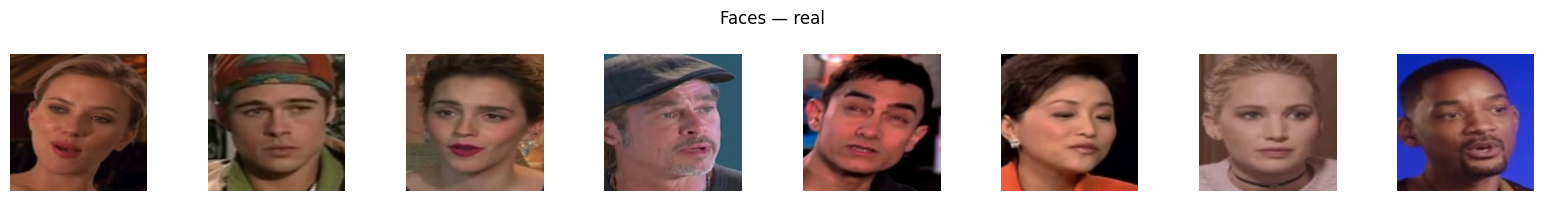

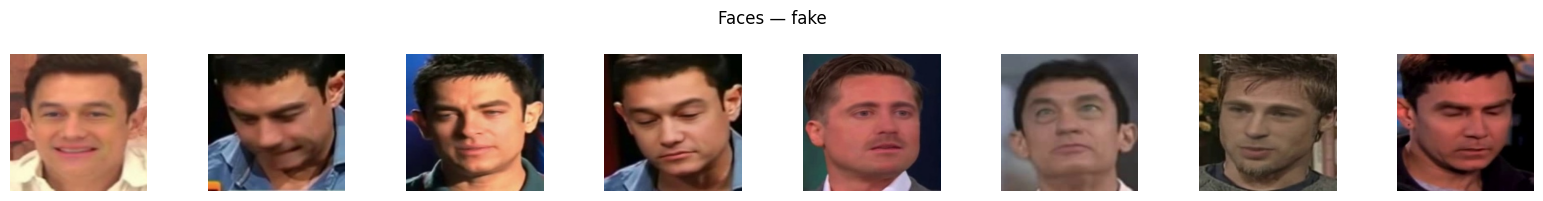

In [ ]:
# ✅ Visual Sanity Check
def show_sample_faces(split="real", n=8):
    face_dir = os.path.join(OUT_FACES, split)
    images   = list(Path(face_dir).rglob("*.jpg"))
    if not images: print(f"No images in {face_dir}"); return
    sample   = random.sample(images, min(n, len(images)))
    fig, axes = plt.subplots(1, len(sample), figsize=(2*len(sample), 2))
    if len(sample) == 1: axes = [axes]
    for ax, p in zip(axes, sample):
        img = cv2.imread(str(p))
        ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); ax.axis("off")
    plt.suptitle(f"Faces — {split}"); plt.tight_layout(); plt.show()

show_sample_faces("real")
show_sample_faces("fake")